In [10]:
#نستدعي كل المكتبات 
import pandas as pd
import seaborn as sns
import sklearn 

In [11]:
# نقرا الملف اول سته اسطر
df = pd.read_csv("advertising.csv")
df.head(6)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2


In [12]:
#نشوف فيه null
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [13]:
#راح نحدد x  و y في معالدله y=b0+b1*x
x = df[["TV","Radio","Newspaper"]]
y = df["Sales"] 

In [14]:
#  train_test_split راح نقسم البيانات الى تدريب و اختبار 
from sklearn.model_selection import  train_test_split

xtrain , xtest , ytrain , ytest = train_test_split(x , y , train_size = 0.8 , random_state = 15)



In [18]:
# الحين راح نبني نموذج الانحدار 
from sklearn.linear_model import LinearRegression

model = LinearRegression()


model.fit(xtrain.values, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
#راح نطلع b0 b1 
model.intercept_


np.float64(4.403301064986735)

In [27]:
#راح نطلع b0 b1 
model.coef_

array([0.05579385, 0.10182203, 0.00415545])

In [30]:
# الحين نقدر نتنبئ و نبي نشوف لو دفعنا 120 دولار لاعلانات تلفزيون و 50 راديو و 60 للجرايد كم المبيعات
advertisment = [[120 , 50 , 60]]
pred = model.predict(advertisment)
pred
#وكذا راخ يتنبئ 

array([16.43899165])

In [33]:
##  بعد ماتنبئ نبي نقيم الخط المستقيم (تقييس اداء البيانات) 
# راح نخليه يتنبئ على بيانات الاختبار xtest
ypred = model.predict(xtest.values)
ypred

array([ 9.48014798,  9.74034749,  9.578992  ,  7.61412598,  8.9161981 ,
       18.10349948, 23.80639906,  8.45058944,  9.52481395, 14.02638709,
        5.91173779,  9.33890342, 21.63371306, 18.5788581 , 21.3716781 ,
       15.41198661, 15.90374543, 12.37618248, 20.85725333, 24.77805334,
        8.8089096 , 23.77526226,  9.57401827, 18.23968951, 18.18553619,
       13.03492642, 23.14573163,  9.20376162, 15.20778442, 18.26570686,
        6.28886805, 21.79104406,  9.8413285 , 12.11724872, 19.19663564,
       10.32455902, 11.52696495, 13.73223973, 22.41892146,  7.04160649])

In [39]:
#نسوي اطار نفارن بين البيانات الفعليه  و التنبؤ و نوضح الفرق
diif = pd.DataFrame({
    "actual": ytest ,
    "predict": ypred

    
})
diif.head(6)

,actual,predict
49,9.7,9.480148
191,11.9,9.740347
12,9.2,9.578992
172,7.6,7.614126
127,11.9,8.916198
40,16.6,18.103499


<Axes: xlabel='Sales'>

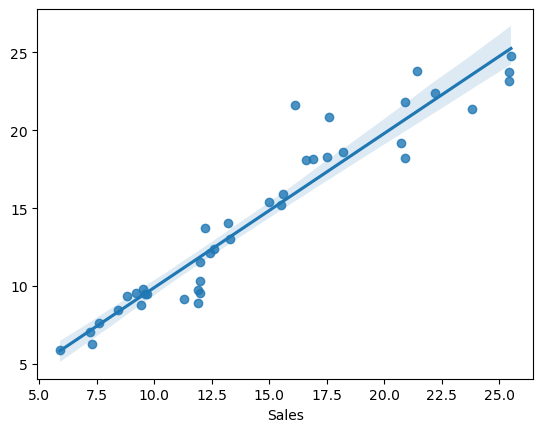

In [40]:
sns.regplot(x = ytest , y = ypred )

In [43]:
# يعد ما وضحنا الفرق الان نقيس الاداء 
#  يعني تقيس مسافه النفاط عن الخط
#mae يجمعهم ثم يقسم على عددهم 
#rmse يحط على الايرور تربيع ثم يجمع و يقسم على عددهم و بالنهايه يحط جذر  وهذا من نمباي
from sklearn import metrics
import numpy as np

mae = metrics.mean_absolute_error(ytest , ypred)

mse = metrics.mean_squared_error(ytest , ypred)

rmse = np.sqrt(mse)

print("the mae :", mae)
print("the mse :", mse)
print("the rmse:", rmse)


the mae : 1.1694394885747708
the mse : 2.711109905368365
the rmse: 1.6465448385538626
